# Comparing within-cluster variance of clusters defined by antigenic and sequence space

## Package Imports

In [1]:
import os
# Typing
from typing import Tuple, Optional
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Machine learning
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
)

from antigentools.antigen_reader import AntigenReader

## Define helper functions
Some of these to go in antigentools later...

In [2]:
def calculate_fitness_of_tips(
    tips_df: pd.DataFrame, 
    host_coordinates: Tuple[float, float],
    ag1_col: str = 'ag1', 
    ag2_col: str = 'ag2',
    s: float = 0.07, 
    homologous_immunity: float = 0.95
) -> pd.DataFrame:
      """
      Calculate fitness of tips based on infection risk against 
  host coordinates.
      
      Parameters:
      - tips_df: DataFrame with ag1, ag2 columns
      - host_coordinates: tuple of (ag1, ag2) for host immune 
  memory
      - s: smith_conversion factor
      - homologous_immunity: float between 0 and 1
      
      Returns:
      - Copy of tips_df with added 'fitness' column
      """
      # Create a copy of the dataframe
      result_df = tips_df.copy()

      # Calculate Euclidean distance from each tip to host coordinates
      distances = ((tips_df[ag1_col] - host_coordinates[0])**2 +
                    (tips_df[ag2_col] - host_coordinates[1])**2)**0.5

      # Calculate risk of infection (equivalent to fitness in thiscontext)
      risk = distances * s
      min_risk = 1.0 - homologous_immunity
      risk = np.maximum(min_risk, risk)
      risk = np.minimum(1.0, risk)

      # Add fitness column
      result_df['fitness'] = risk

      return result_df

In [3]:
def plot_fitness_landscape(
      tips_df: pd.DataFrame, 
      hosts_df: pd.DataFrame, 
      sample_year: float,
      ag1_col: str = 'ag1',
      ag2_col: str = 'ag2',
      s: float = 0.1,  # Default smith conversion
      homologous_immunity: float = 0.95,  # Default homologous immunity
      figsize: Tuple[int, int] = (10, 8),
      deme: str = 'total'
  ) -> Tuple[pd.DataFrame, Tuple[float, float]]:
      """
      Calculate fitness and plot the antigenic landscape for a 
  specific year.
      
      Parameters:
      - tips_df: DataFrame with virus tip data including ag1, ag2 
  columns
      - hosts_df: DataFrame with host immune memory data
      - sample_year: Year to analyze
      - s: smith_conversion factor (default: 0.1)
      - homologous_immunity: float between 0 and 1 (default: 0.95)
      - figsize: Figure size tuple (default: (10, 8))
      - deme: Which deme to use for host coordinates (default: 
  'total')
      
      Returns:
      - fitness_df: DataFrame with fitness values added
      - host_coordinates: Tuple of (ag1, ag2) for host centroid
      """
      # Get host centroid for the specified year
      total_hosts_df = hosts_df.query(f"deme == '{deme}' and year == {sample_year}")

      if len(total_hosts_df) == 0:
          raise ValueError(f"No host data found for year {sample_year} and deme '{deme}'")

      host_coordinates = (total_hosts_df['ag1'].values[0], total_hosts_df['ag2'].values[0])

      # Calculate fitness
      fitness_df = calculate_fitness_of_tips(tips_df, host_coordinates, ag1_col=ag1_col, ag2_col=ag2_col, s=s, homologous_immunity=homologous_immunity)

      # Create the plot
      plt.figure(figsize=figsize)

      # Plot tips as regular points colored by fitness
      scatter = plt.scatter(fitness_df[ag1_col], fitness_df[ag2_col],
                           c=fitness_df['fitness'], cmap='RdBu',
                           edgecolor='k', alpha=0.6, label='Viruses')

      # Add colorbar
      plt.colorbar(scatter, label='Fitness')

      # Plot host centroid as red X
      plt.scatter(total_hosts_df['ag1'], total_hosts_df['ag2'],
                 marker='x', c='red', s=250, linewidths=3,
                 label='Host Immunity')

      # Add labels and title
      plt.xlabel('ag1')
      plt.ylabel('ag2')
      plt.title(f'Antigenic Space with Fitness (t={sample_year})')
      plt.legend()

      # Add grid for better readability
      plt.grid(True, alpha=0.3)

      # Show the plot
      plt.show()

      return fitness_df, host_coordinates

In [4]:
def calculate_internal_cluster_fitness_metrics(df, cluster_col, fitness_col='fitness'):
    """
    Calculate R², Adj-R², and BIC for fitness prediction by clusters.
    Treats clusters as categorical predictors (like ANOVA).

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing fitness and cluster assignments.
    cluster_col : str
        Column name with cluster assignments.
    fitness_col : str
        Column name with fitness values.    

    Returns:
    --------
    dict
        Dictionary with keys: 'r2', 'adj_r2', 'bic', 'n_clusters', 'n_params', 'rmse'
        and their corresponding values.
    """
    y = df[fitness_col].values
    cluster_labels = df[cluster_col].values
    
    n = len(df)
    n_clusters = len(np.unique(cluster_labels))
    
    # Predict fitness using cluster means
    cluster_means = df.groupby(cluster_col)[fitness_col].mean()
    y_pred = df[cluster_col].map(cluster_means).values
    
    # Calculate R²
    tss = np.sum((y - y.mean())**2)
    rss = np.sum((y - y_pred)**2)
    r2 = 1 - (rss / tss) # Will be NaN if tss is 0 (no variance in y)
    
    # Calculate Adjusted R²
    # n_params = n_clusters (one mean per cluster)
    n_params = n_clusters
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n_params < n - 1 else 0
    
    # Calculate BIC
    sigma2 = rss / n + 1e-10  # Add epsilon for stability
    log_likelihood = -n/2 * (np.log(2*np.pi*sigma2) + 1)
    bic = -2 * log_likelihood + n_params * np.log(n)
    
    return {
        'r2': r2,
        'adj_r2': adj_r2,
        'bic': bic,
        'n_clusters': n_clusters,
        'n_params': n_params,
        'rmse': np.sqrt(sigma2)
    }

In [5]:
def cluster_embeddings(embeddings_df: pd.DataFrame, 
                       embedding_method: str, 
                       k_optimal: Optional[int] = None,
                       max_k: int = 30,
                       plot_only: bool = False,
                       random_state: int = 42) -> pd.DataFrame:
    """
    Cluster embeddings using K-means based on columns matching a specified prefix.
    
    If k_optimal is not provided, uses Ward's linkage hierarchical clustering
    to automatically determine the optimal number of clusters based on the
    dendrogram gap criterion (largest gap in linkage distances).
    
    Parameters:
    -----------
    embeddings_df : pd.DataFrame
        DataFrame containing embedding columns
    embedding_method : str
        Prefix of embedding columns to use for clustering (e.g., 'mds', 'pca', 'umap')
    k_optimal : Optional[int], default=None
        Number of clusters for K-means. If None, automatically determined using
        Ward's linkage analysis.
    max_k : int, default=10
        Maximum number of clusters to consider when auto-determining k
    plot_only : bool, default=False
        If True, only plot the elbow method figure without performing clustering and return None
    random_state : int, default=0
        Random state for reproducibility
        
    Returns:
    --------
    pd.DataFrame
        Input dataframe with added 'variant_seq' column containing cluster labels
    """
    # Get all columns that start with the embedding_method prefix
    embed_cols_to_use = [col for col in embeddings_df.columns if col.startswith(embedding_method)]
    
    if len(embed_cols_to_use) == 0:
        raise ValueError(f"No columns found with prefix '{embedding_method}'")
    
    # Extract the embedding data
    X = embeddings_df[embed_cols_to_use].values
    
    # Determine optimal k if not provided
    if k_optimal is None:
        # Perform Ward's linkage
        Z = linkage(X, method='ward')
        
        # Find optimal k by looking at the largest gap in linkage distances
        # The linkage matrix Z has distances in column 2
        distances = Z[:, 2]
        
        # Calculate gaps between consecutive merges
        gaps = np.diff(distances)
        
        # Find the largest gap (but don't exceed max_k clusters)
        # The index of the largest gap tells us where to cut the dendrogram
        # We look at the last max_k-1 merges (since n_clusters = n_samples - merge_step)
        if len(gaps) >= max_k:
            gaps_to_consider = gaps[-(max_k-1):]
            largest_gap_idx = np.argmax(gaps_to_consider)
            k_optimal = largest_gap_idx + 2  # +2 because we start from 2 clusters
        else:
            largest_gap_idx = np.argmax(gaps)
            k_optimal = len(distances) - largest_gap_idx
            
        print(f"Automatically determined k_optimal = {k_optimal} using Ward's linkage")
        # Create elbow plot
        plt.figure(figsize=(10, 5))
        last_original = gaps[-(max_k-1):]  # Last merges
        plt.plot(range(1, max_k), last_original[::-1], 'bo-')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Linkage distance (WSS)')
        plt.title('Elbow Method for Optimal k')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    if plot_only:
        return None
    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k_optimal, random_state=random_state).fit(X)
    
    # Add cluster labels to dataframe
    embeddings_df = embeddings_df.copy()
    embeddings_df[f'variant_{embedding_method}'] = kmeans.labels_
    
    return embeddings_df

In [6]:
def plot_variant_assignments(df, variant_methods, figsize=(16, 5), fig_path=None, palette=None):
    """
    Plot variant assignments with points colored by variant, plus fitness landscape.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with ag1, ag2, fitness, and variant_* columns
    variant_methods : list of str
        List of variant column names to plot (e.g., ['variant_ag', 'variant_mds'])
    figsize : tuple
        Figure size (width, height)
    fig_path : str, optional
        Path to save the figure (if None, figure is not saved)
    palette : list of str or dict, optional
        Color palette for variants. If list, colors assigned in order.
        If dict, maps variant labels to colors. If None, uses 'tab10' colormap.
    """
    n_methods = len(variant_methods) + 1  # +1 for fitness panel
    fig, axes = plt.subplots(1, n_methods, figsize=figsize, sharey=True)
    
    if n_methods == 1:
        axes = [axes]
    
    # Plot variant assignments
    for idx, method in enumerate(variant_methods):
        ax = axes[idx]
        
        # Get unique variants
        variants = sorted(df[method].unique())
        n_variants = len(variants)
        
        # Determine colors
        if palette is None:
            # Use tab10 colormap for up to 10 variants
            cmap = plt.cm.get_cmap('tab10')
            colors = [cmap(i % 10) for i in range(n_variants)]
        elif isinstance(palette, dict):
            colors = [palette.get(v, 'gray') for v in variants]
        else:
            colors = [palette[i % len(palette)] for i in range(n_variants)]
        
        # Create scatter plot for each variant with different color
        for i, variant in enumerate(variants):
            variant_data = df[df[method] == variant]
            
            ax.scatter(
                variant_data['ag1'], 
                variant_data['ag2'],
                c=[colors[i]],
                s=100,
                alpha=0.7,
                edgecolors='black',
                label=f'Variant {variant}'
            )
        
        # Formatting
        ax.set_xlabel('ag1', fontsize=11, weight='600')
        if idx == 0:
            ax.set_ylabel('ag2', fontsize=11, weight='600')
        
        # Clean method name for title
        method_name = method.replace('variant_', '').upper()
        if method_name == 'AG' or method_name == 'VARIANT':
            method_name = 'Antigenic'
        ax.set_title(f'{method_name} Variants', fontsize=12, weight='bold')
        
        # Remove top and right spines
        sns.despine(ax=ax)
        
        # Add legend
        ax.legend(loc='upper right', fontsize=8, framealpha=0.5, ncol=1)
    
    # Plot fitness landscape in last panel
    ax = axes[-1]
    scatter = ax.scatter(
        df['ag1'],
        df['ag2'],
        c=df['fitness'],
        cmap='RdBu',
        s=100,
        alpha=0.7,
        edgecolors='black',
        vmin=df['fitness'].min(),
        vmax=df['fitness'].max()
    )
    
    # Add colorbar for fitness
    cbar = plt.colorbar(scatter, ax=ax, label='Fitness')
    
    # Formatting
    ax.set_xlabel('ag1', fontsize=11, weight='600')
    ax.set_title('Fitness Landscape', fontsize=12, weight='bold')
    
    # Remove top and right spines
    sns.despine(ax=ax)
    
    plt.tight_layout()
    if fig_path is not None:
        plt.savefig(fig_path, dpi=300)
    plt.show()

In [7]:
def relabel_variants_by_temporal_order(df, variant_col, time_col='year'):
    """
    Relabel variant assignments based on temporal order.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing variant assignments and time values
    variant_col : str
        Name of column containing variant labels to relabel
    time_col : str, default='year'
        Name of column containing time values for ordering
        
    Returns
    -------
    pd.DataFrame
        DataFrame with relabeled cluster column
        
    Examples
    --------
    >>> df = relabel_clusters_by_temporal_order(tips_df, 'variant_ag')
    >>> df = relabel_clusters_by_temporal_order(tips_df, 'variant_ag', time_col='date')
    """
    # Calculate avg time per cluster and sort
    variant_avg_time = df.groupby(variant_col)[time_col].mean().sort_values()
    
    # Create mapping from old to new labels
    label_mapping = {old_label: new_label 
                     for new_label, old_label in enumerate(variant_avg_time.index)}

    # Apply mapping
    df = df.copy()
    df[variant_col] = df[variant_col].map(label_mapping)

    return df

## Load data

In [8]:
# Define data paths
build = 'flu-simulated-150k-samples-final'
variant_color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"

# Output paths
fig_path = "../../antigen-tex/figures/"
out_path = f"../results/{build}/"

# Antigen outputs
tips_path = f"../data/{build}/antigen-outputs/viruses.csv"
histories_path = f"../data/{build}/antigen-outputs/histories.csv"

# Pathogen embed outputs
mds_embeddings_path = f"../data/{build}/pathogen-embed/mds-embeddings.csv"
pca_embeddings_path = f"../data/{build}/pathogen-embed/pca-embeddings.csv"
tsne_embeddings_path = f"../data/{build}/pathogen-embed/t-sne-embeddings.csv"
umap_embeddings_path = f"../data/{build}/pathogen-embed/umap-embeddings.csv"

# Load variant color map
color_map_df = pd.read_csv(variant_color_map_path, sep="\t")
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")

Created color map with 30 entries


In [9]:
# Load tips and pruned variant fitness data
tips_df = pd.read_csv(tips_path)
# Subset to unique sequences only for clustering
tips_df = tips_df.drop_duplicates(subset=['nucleotideSequence']).reset_index(drop=True)
print(f"Loaded {len(tips_df)} unique sequences from tips data")
tips_df.head()

Loaded 5475 unique sequences from tips data


,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,epitopeMutationCount,nonepitopeMutationCount,lowEpitopeMutationCount,highEpitopeMutationCount,country,aa_seq,variant
0,257eb400,-0.0362,0,1,0,1,60.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.7636,0.1655,9,1,0,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2
1,3efb165d,-0.0360,0,1,0,0,1392.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,10,1,0,0,north,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2
2,1e0b518b,-0.0253,0,1,0,1,33.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,10,1,0,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2
3,576c71ea,-0.0185,0,1,0,1,1589.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,10,2,0,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2
4,78d1ddb0,-0.0085,0,0,0,1,32.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,10,2,0,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2


In [10]:
# Load in histories
histories_df = pd.read_csv(histories_path)
# In the bugged version, we recorded burnin. We need to remove those entries (year < 10) and then renumber years
histories_df = histories_df[histories_df['year'] >= 10].copy()
histories_df['year'] = histories_df['year'] - 10
print(f"Loaded {len(histories_df)} history entries after removing burnin")
histories_df.head()

Loaded 120 history entries after removing burnin


,year,deme,ag1,ag2,naive_fraction,experienced_hosts
40,0.0,north,7.150296,0.635567,0.1141,8859
41,0.0,tropics,6.549347,0.452353,0.1396,8604
42,0.0,south,8.712495,0.442429,0.0889,9111
43,0.0,total,7.491330,0.510029,0.1142,26574
44,1.0,north,7.390172,0.599102,0.1408,8592


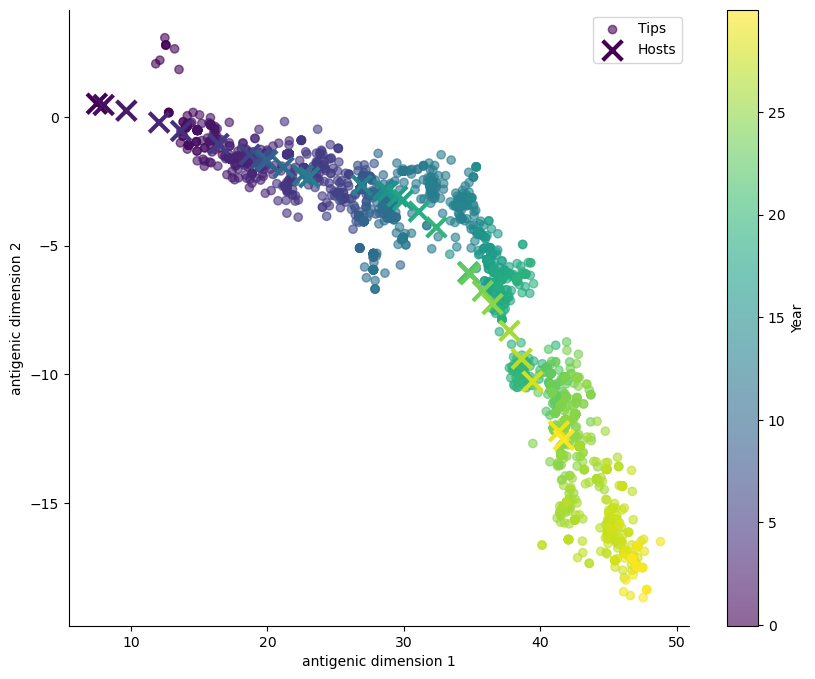

In [11]:
# Create the plot
plt.figure(figsize=(10, 8))
total_hosts_df = histories_df.copy()
total_hosts_df = total_hosts_df.query("deme == 'total'")

# Plot tips_df as regular points
scatter = plt.scatter(tips_df['ag1'], tips_df['ag2'], c=tips_df['year'], cmap='viridis', alpha=0.6, label='Tips')

# Add colorbar for the tips
plt.colorbar(scatter, label='Year')

# Plot hosts_df as big red X markers
host_scatter = plt.scatter(total_hosts_df['ag1'], total_hosts_df['ag2'], marker='x', c=total_hosts_df['year'], cmap='viridis', s=200,
linewidths=3, label='Hosts')

# Add labels and title
plt.xlabel('antigenic dimension 1')
plt.ylabel('antigenic dimension 2')
#plt.title('Antigenic Space (Host Centroids are Most Recent Exposures)')
plt.legend()

# remove splines from top and right
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Add grid for better readability
plt.grid(False)

# Show the plot
plt.show()

## Define k for ground truth assignment

In [12]:
# Cluster both original and noisy data with Kmeans (create elbow plot)
feature_cols = ['ag1', 'ag2']
X_original = tips_df[feature_cols].values

linkage_matrix_original = linkage(X_original, method='ward')

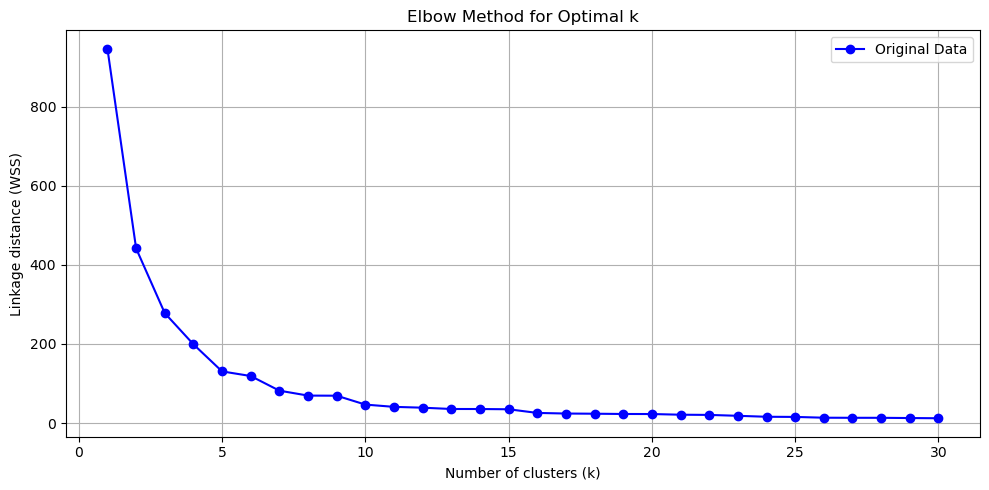

In [13]:
# Create elbow plot
plt.figure(figsize=(10, 5))
last_original = linkage_matrix_original[-30:, 2]  # Last 30 merges
plt.plot(range(1, 31), last_original[::-1], 'bo-', label='Original Data')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Linkage distance (WSS)')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# Set k=8 based on elbow plot
k_optimal = 20
# Cluster original data with k=20 for forecasting
kmeans_original = KMeans(n_clusters=k_optimal, random_state=42)
# Cluster noisy data
kmeans_noisy = KMeans(n_clusters=k_optimal, random_state=42)
tips_df['variant_ag'] = kmeans_original.fit_predict(X_original)

### MDS Embeddings

In [15]:
# Load in embeddings
mds_embeddings_df = pd.read_csv(mds_embeddings_path)
# Rename strain column to name for consistency
mds_embeddings_df.rename(columns={'strain': 'name'}, inplace=True)
# Only keep mds1 and mds2
#mds_embeddings_df = mds_embeddings_df[['name', 'mds1', 'mds2', 'mds3']]
mds_embeddings_df.head()

,name,mds1,mds2,mds3,mds4,mds5,mds6,mds7,mds8,mds9,mds10
0,257eb400,5.402041,-3.505700,2.170958,3.447699,6.022617,8.763818,4.270188,-0.131164,2.993600,-4.778698
1,3efb165d,5.005239,-3.180197,2.431453,3.792284,5.548881,7.650033,4.431502,-0.630361,2.643705,-4.353570
2,6b141244,5.641446,-3.628573,3.235169,3.829314,6.276602,8.170606,3.809917,-1.029420,2.747897,-4.674039
3,28ecc71f,5.957597,-3.784623,2.960097,4.216205,5.847058,7.760782,4.134856,-0.675075,3.225588,-4.728794
4,fe3066d,5.758019,-3.588082,2.790696,4.491703,5.855816,7.856960,5.679113,0.152581,1.517703,-4.091094


In [16]:
mds_embeddings_df = cluster_embeddings(
    mds_embeddings_df,
    embedding_method='mds',
    k_optimal=20,
    random_state=42
)
mds_embeddings_df.head()

,name,mds1,mds2,mds3,mds4,mds5,mds6,mds7,mds8,mds9,mds10,variant_mds
0,257eb400,5.402041,-3.505700,2.170958,3.447699,6.022617,8.763818,4.270188,-0.131164,2.993600,-4.778698,3
1,3efb165d,5.005239,-3.180197,2.431453,3.792284,5.548881,7.650033,4.431502,-0.630361,2.643705,-4.353570,3
2,6b141244,5.641446,-3.628573,3.235169,3.829314,6.276602,8.170606,3.809917,-1.029420,2.747897,-4.674039,3
3,28ecc71f,5.957597,-3.784623,2.960097,4.216205,5.847058,7.760782,4.134856,-0.675075,3.225588,-4.728794,3
4,fe3066d,5.758019,-3.588082,2.790696,4.491703,5.855816,7.856960,5.679113,0.152581,1.517703,-4.091094,3


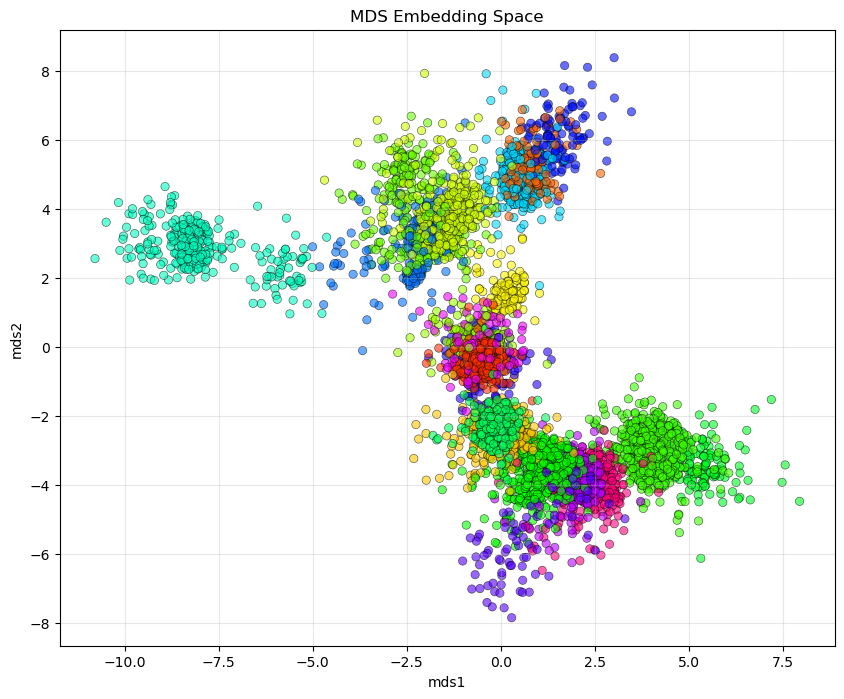

In [17]:
# Create the plot
plt.figure(figsize=(10, 8))

# Plot tips_df as regular points
scatter = sns.scatterplot(data=mds_embeddings_df, x='mds1', y='mds2', hue='variant_mds', palette=color_map, edgecolor='k', alpha=0.6, legend=False)

# Add labels and title
plt.xlabel('mds1')
plt.ylabel('mds2')
plt.title('MDS Embedding Space')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

### PCA Embeddings

In [18]:
# Load in embeddings
pca_embeddings_df = pd.read_csv(pca_embeddings_path)
# Rename strain column to name for consistency
pca_embeddings_df.rename(columns={'strain': 'name'}, inplace=True)
#pca_embeddings_df = pca_embeddings_df[['name', 'pca1', 'pca2']]
pca_embeddings_df.head()

,name,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10
0,257eb400,-6.043307,3.121621,0.712802,-1.638677,-1.802942,-1.562757,3.520165,-1.191968,0.690172,-1.378153
1,3efb165d,-6.032127,3.102009,0.701342,-1.616015,-1.780904,-1.536583,3.468913,-1.148148,0.667166,-1.333325
2,6b141244,-6.032232,3.101229,0.704437,-1.615509,-1.785390,-1.538906,3.474729,-1.155266,0.669483,-1.338590
3,28ecc71f,-6.032275,3.104335,0.702841,-1.614701,-1.783513,-1.536650,3.474647,-1.153884,0.668001,-1.342842
4,fe3066d,-6.032498,3.104314,0.700527,-1.617266,-1.784446,-1.538587,3.474578,-1.151164,0.666989,-1.334676


In [19]:
# Cluster with k=20
pca_embeddings_df = cluster_embeddings(
    pca_embeddings_df,
    embedding_method='pca',
    k_optimal=20,
    random_state=42
)
pca_embeddings_df.head()

,name,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,variant_pca
0,257eb400,-6.043307,3.121621,0.712802,-1.638677,-1.802942,-1.562757,3.520165,-1.191968,0.690172,-1.378153,3
1,3efb165d,-6.032127,3.102009,0.701342,-1.616015,-1.780904,-1.536583,3.468913,-1.148148,0.667166,-1.333325,3
2,6b141244,-6.032232,3.101229,0.704437,-1.615509,-1.785390,-1.538906,3.474729,-1.155266,0.669483,-1.338590,3
3,28ecc71f,-6.032275,3.104335,0.702841,-1.614701,-1.783513,-1.536650,3.474647,-1.153884,0.668001,-1.342842,3
4,fe3066d,-6.032498,3.104314,0.700527,-1.617266,-1.784446,-1.538587,3.474578,-1.151164,0.666989,-1.334676,3


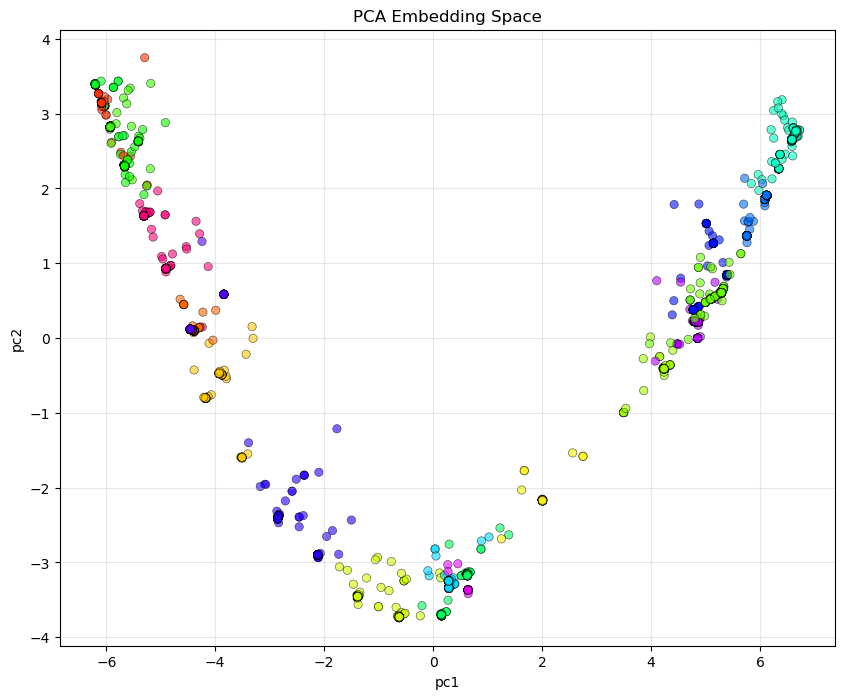

In [20]:
plt.figure(figsize=(10, 8))

# Plot tips_df as regular points
scatter = sns.scatterplot(data=pca_embeddings_df, x='pca1', y='pca2', hue='variant_pca', palette=color_map, edgecolor='k', alpha=0.6, legend=False)

# Add labels and title
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('PCA Embedding Space')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

### t-SNE Embeddings

In [21]:
# Load in t-SNE embeddings
tsne_embeddings = pd.read_csv(tsne_embeddings_path)
# Rename tsne_x and tsne_y to tsne1 and tsne2
tsne_embeddings.rename(columns={'strain': 'name', 'tsne_x': 'tsne1', 'tsne_y': 'tsne2'}, inplace=True)
tsne_embeddings.head()

,name,tsne1,tsne2
0,257eb400,-9.753149,47.491733
1,3efb165d,-8.653048,45.790706
2,6b141244,-8.593219,46.163932
3,28ecc71f,-8.601089,46.149030
4,fe3066d,-8.601109,46.149056


In [22]:
# Cluster t-SNE with k=20
tsne_embeddings = cluster_embeddings(
    tsne_embeddings,
    embedding_method='tsne',
    k_optimal=20,
    random_state=42
)
tsne_embeddings.head()

,name,tsne1,tsne2,variant_tsne
0,257eb400,-9.753149,47.491733,8
1,3efb165d,-8.653048,45.790706,8
2,6b141244,-8.593219,46.163932,8
3,28ecc71f,-8.601089,46.149030,8
4,fe3066d,-8.601109,46.149056,8


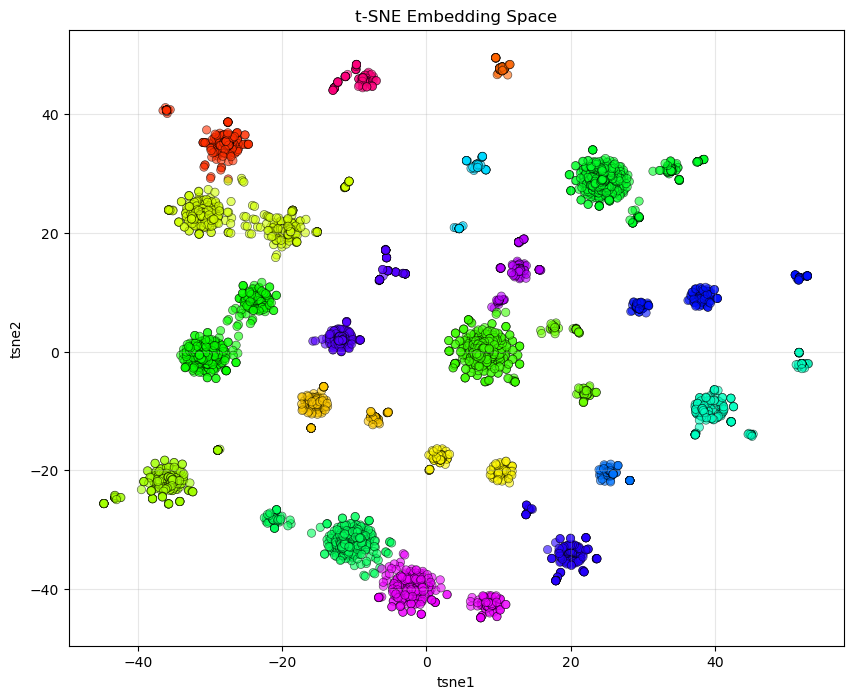

In [23]:
# Plot t-SNE embeddings
plt.figure(figsize=(10, 8))

# Plot tips_df as regular points
scatter = sns.scatterplot(data=tsne_embeddings, x='tsne1', y='tsne2', hue='variant_tsne', palette=color_map, edgecolor='k', alpha=0.6, legend=False)

# Add labels and title
plt.xlabel('tsne1')
plt.ylabel('tsne2')
plt.title('t-SNE Embedding Space')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

### UMAP Embeddings

In [24]:
# Load umap embeddings
umap_embeddings = pd.read_csv(umap_embeddings_path)
# Replace umap_x and umap_y with umap1 and umap2
umap_embeddings.rename(columns={'strain': 'name', 'umap_x': 'umap1', 'umap_y': 'umap2'}, inplace=True)
umap_embeddings.head()

,name,umap1,umap2
0,257eb400,15.126706,-21.370235
1,3efb165d,16.118510,-19.396450
2,6b141244,15.040022,-21.495071
3,28ecc71f,15.005119,-21.467886
4,fe3066d,14.967616,-21.423998


In [25]:
# Cluster umap embeddings with k=20
umap_embeddings = cluster_embeddings(
    umap_embeddings,
    embedding_method='umap',
    k_optimal=20,
    random_state=42
)

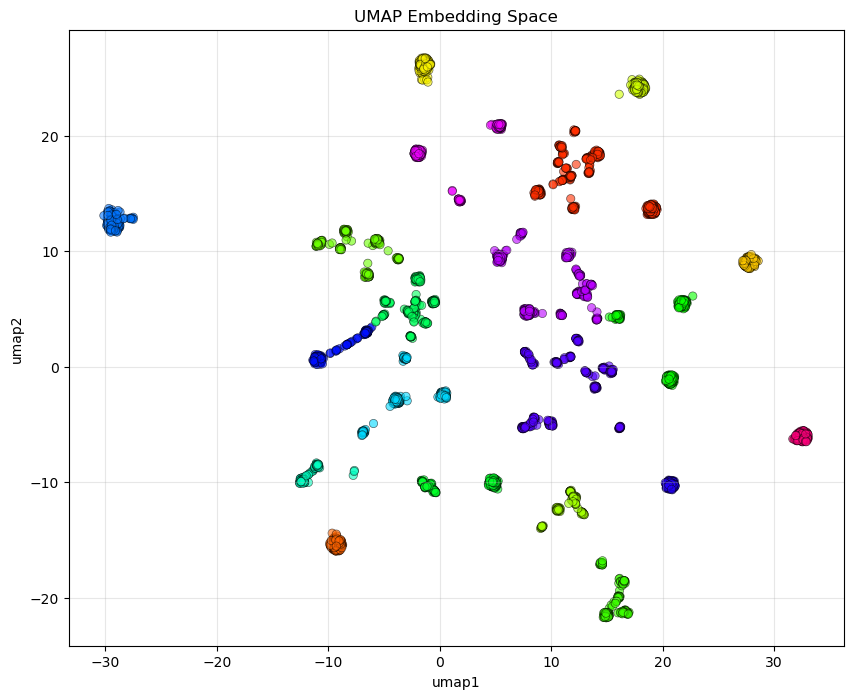

In [26]:
# Plot UMAP embeddings
plt.figure(figsize=(10, 8))

# Plot tips_df as regular points
scatter = sns.scatterplot(data=umap_embeddings, x='umap1', y='umap2', hue='variant_umap', palette=color_map, edgecolor='k', alpha=0.6, legend=False) 

# Add labels and title
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.title('UMAP Embedding Space')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

## Merge cluster assignments from pathogen-embed

In [28]:
# Merge all embedding dfs on name -- subet to relevant columns only: name and variant_*
merged_tips_df = tips_df.copy()
embedding_dfs = [mds_embeddings_df, pca_embeddings_df, tsne_embeddings, umap_embeddings]
for embed_df in embedding_dfs:
    merged_tips_df = merged_tips_df.merge(embed_df[['name', *embed_df.columns[embed_df.columns.str.startswith('variant_')]]], on='name', how='left')

# Relabel variants by temporal order
for variant_col in [col for col in merged_tips_df.columns if col.startswith('variant_')]:
    merged_tips_df = relabel_variants_by_temporal_order(merged_tips_df, variant_col, time_col='year')
merged_tips_df.head()
print(f"Merged tips dataframe has {len(merged_tips_df)} rows")


Merged tips dataframe has 5475 rows


In [29]:
# Write merged tips without row indices
merged_tips_path = f"../data/{build}/tips_variant_assignment_compare.tsv"
merged_tips_df.to_csv(merged_tips_path, sep='\t', index=False)

### Compare cluster assignments in the antigenic space

In [30]:
cluster_labels = ['variant_ag', 'variant_mds', 'variant_pca', 'variant_tsne', 'variant_umap']

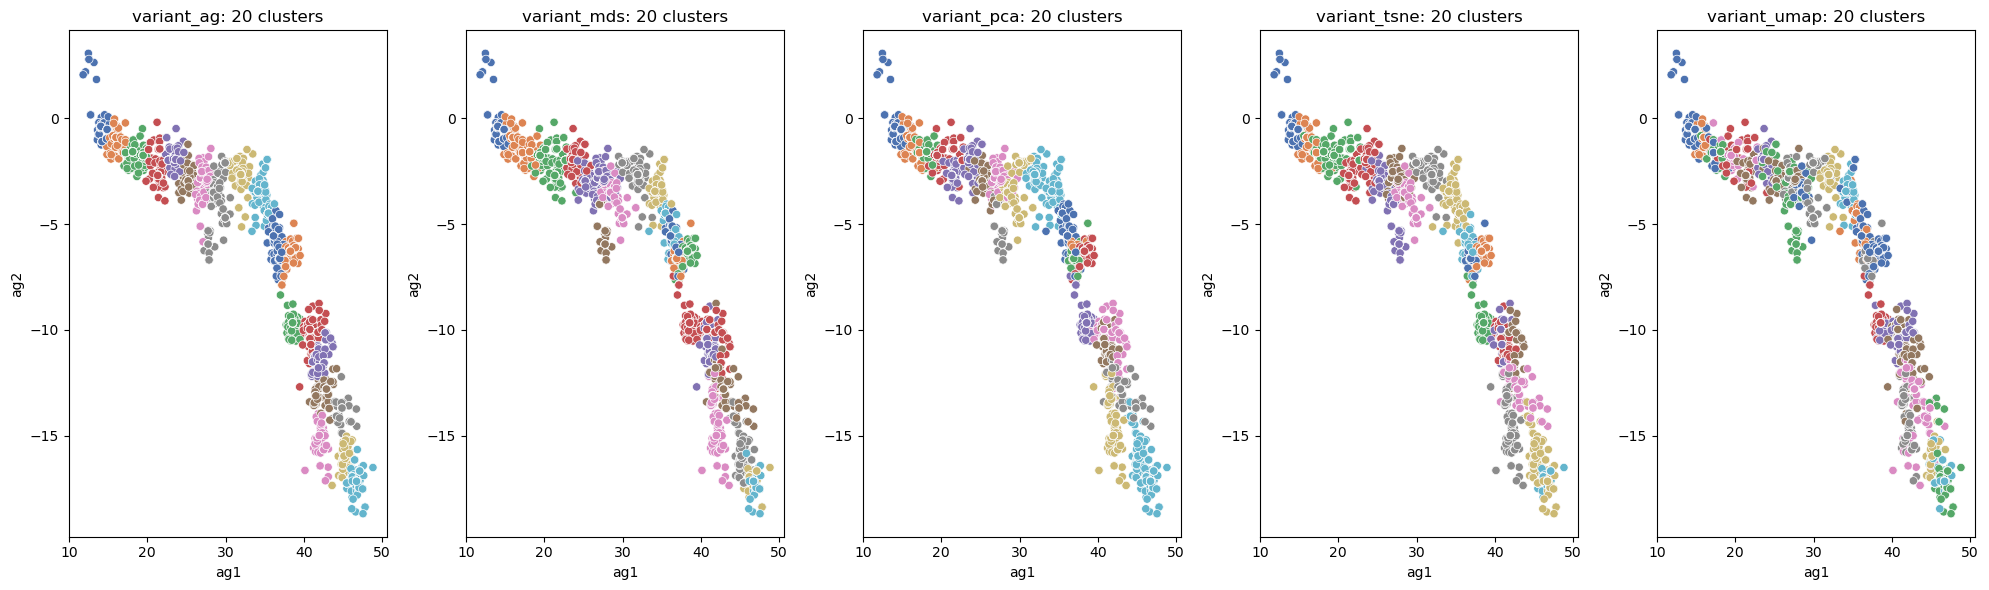

In [31]:
# Plot antigenic space of all cluster labels 
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
axes = axes.flatten()
for i, cluster_label in enumerate(cluster_labels):
    ax = axes[i]
    n_clusters = merged_tips_df[cluster_label].nunique()
    sns.scatterplot(data=merged_tips_df, x='ag1', y='ag2', palette='deep', hue=cluster_label, legend=False, ax=ax)
    ax.set_title(f'{cluster_label}: {n_clusters} clusters')
    ax.set_xlabel('ag1')
    ax.set_ylabel('ag2')

plt.tight_layout()
plt.show()

## Fitness at a snapshot in time

In [32]:
# Try a 5-year window from t=17 to t=22
t = 22.0
snapshot_tips_df = merged_tips_df[(merged_tips_df['year'] >= 17.0) & (merged_tips_df['year'] <= 22.0)].copy()

# Recalculate fitness at t=22 with only data from last 5 years
total_hosts_df = histories_df.query(f"deme == 'total' and year == {t}")
host_coordinates = (total_hosts_df['ag1'].values[0], total_hosts_df['ag2'].values[0])

tips_fitness_df = calculate_fitness_of_tips(snapshot_tips_df, host_coordinates)
tips_fitness_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,...,highEpitopeMutationCount,country,aa_seq,variant,variant_ag,variant_mds,variant_pca,variant_tsne,variant_umap,fitness
3116,2bbcd08e,17.0002,0,1,0,1,92544.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,36.9147,-6.6240,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,18,10,11,12,10,7,0.148037
3117,13ad9cc1,17.0049,0,0,0,1,91506.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,37.1610,-6.3255,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,18,10,10,10,9,10,0.161613
3118,6076db66,17.0313,0,1,0,1,84419.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,36.8225,-6.0903,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,18,10,9,11,9,11,0.137265
3119,d4ea856,17.0528,0,1,0,1,92319.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,36.9147,-6.6240,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,18,10,11,12,10,7,0.148037
3120,7313bbcf,17.0536,0,1,0,0,90114.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,36.1112,-5.5554,...,0,north,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,4,10,9,10,9,11,0.095869


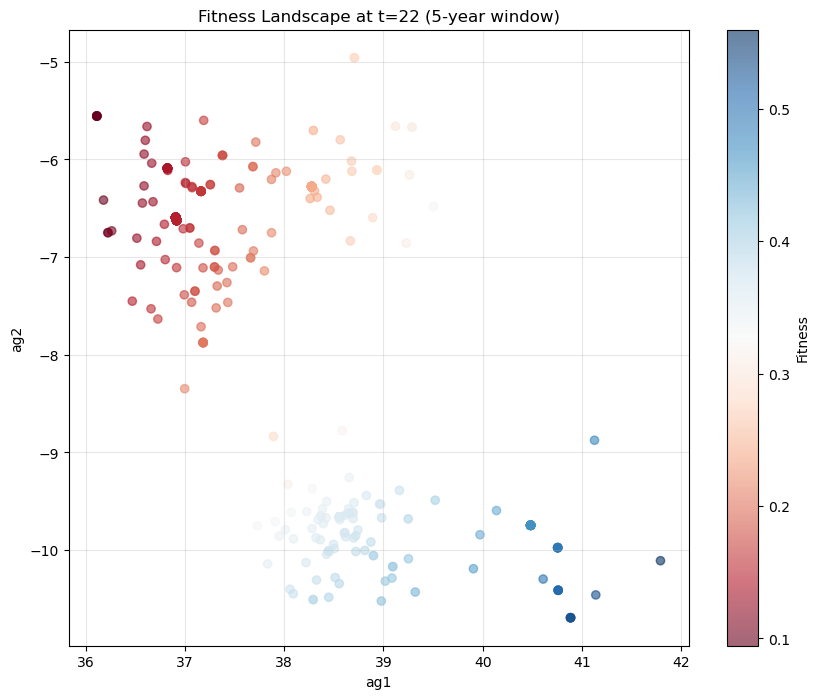

In [33]:
# Plot the fitness landscape
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tips_fitness_df['ag1'], tips_fitness_df['ag2'], c=tips_fitness_df['fitness'], cmap='RdBu', alpha=0.6)
plt.colorbar(scatter, label='Fitness')
plt.xlabel('ag1')
plt.ylabel('ag2')
plt.title('Fitness Landscape at t=22 (5-year window)')
plt.grid(True, alpha=0.3)
plt.show()

### Figure 3: An example of variant assignment

In [34]:
fig3_path = "../../antigen-tex/figures/variant_assignment_example.pdf"
methods_to_plot = ['variant_ag', 'variant_mds', 'variant_umap']

/var/folders/90/6t9_1yk52qd_sbpbmt4ym0540000gn/T/ipykernel_26970/2240716502.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


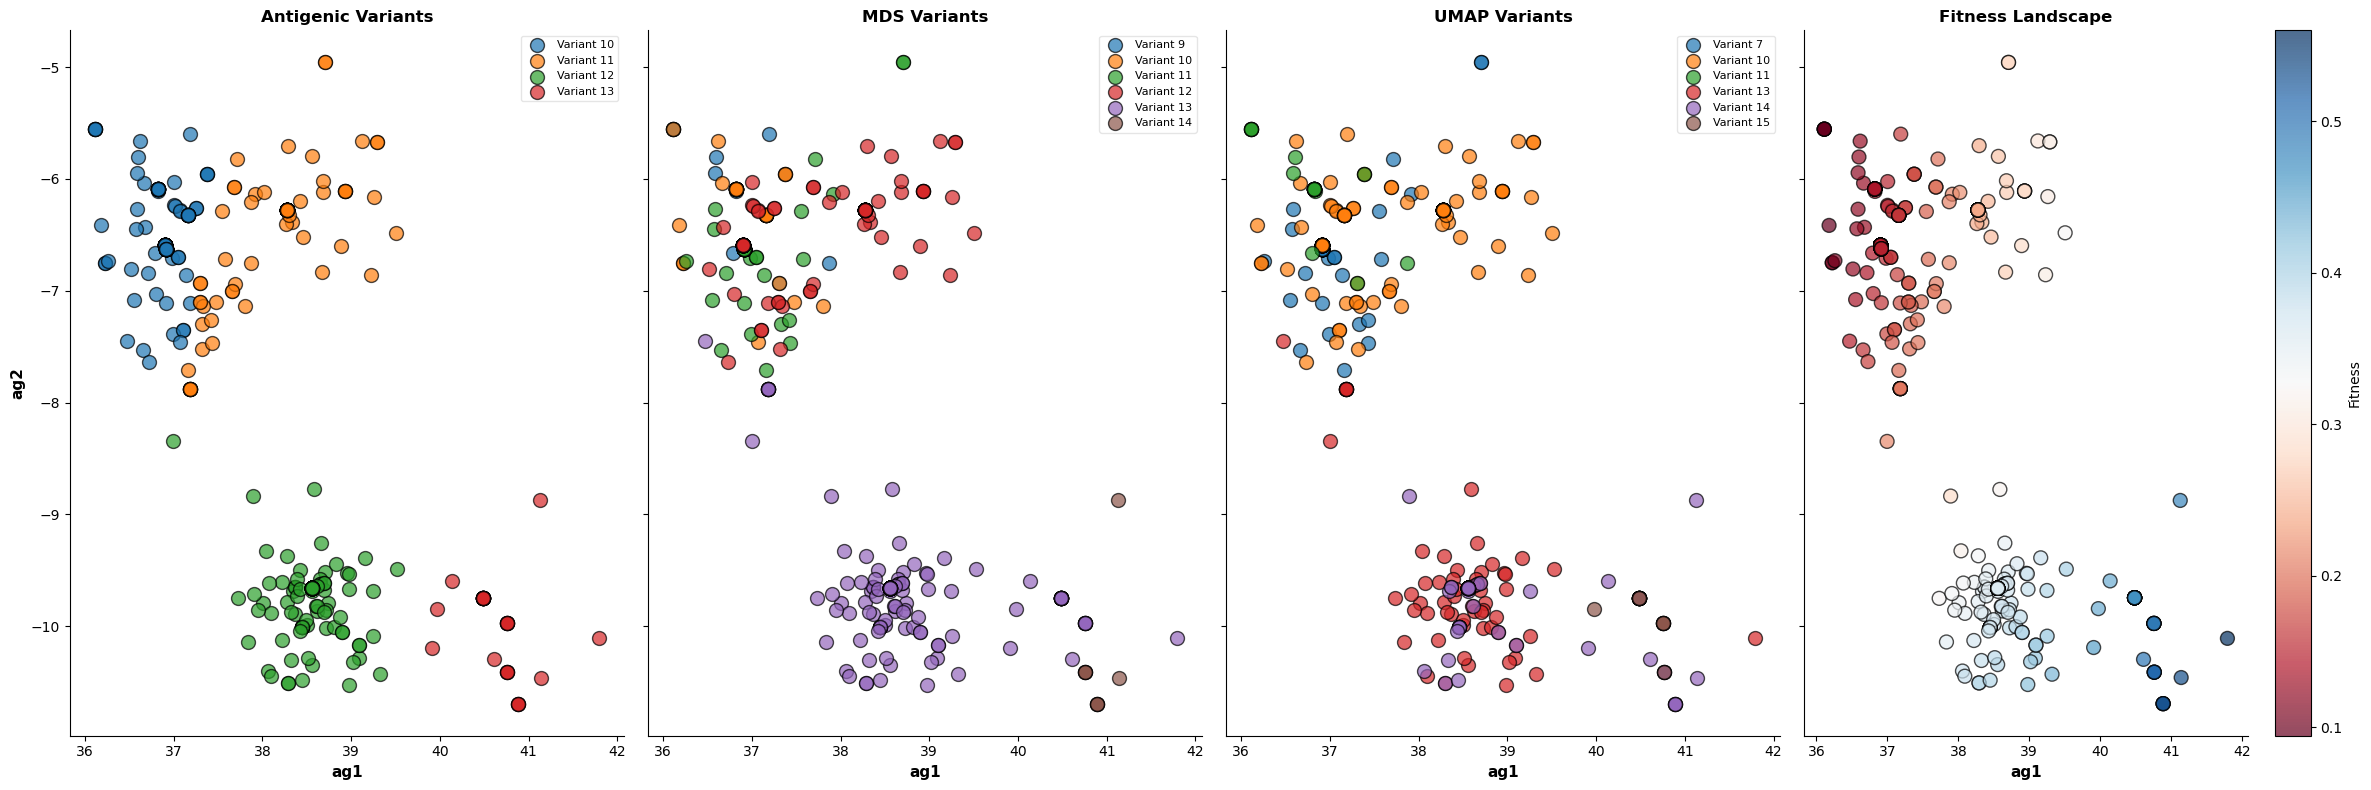

In [35]:
plot_variant_assignments(tips_fitness_df, methods_to_plot, figsize=(24, 8), fig_path=fig3_path)

#### Try a few different metrics in permetrics

* Internal/Index metrics: how well do clusters explain variance in fitness (r2-adj + BIC)
* External/Score metrics: assuming antigen cluster as ground-truth, how well do other methods do at finding the same clusters? (ARI and NMI)

## Iterate over 5 year windows

* Iterate over 5yr windows and calculate $r^2$ for variant assignment methods

In [36]:
step_size = 1
window_length = 5
start_range = window_length
end_range = 30
t_range = range(start_range, end_range, step_size)
print(f"Calculating metrics over time range: {list(t_range)}")

Calculating metrics over time range: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [37]:
diagnostics_dict = {
    't':[],
    'assignment_method':[],
    'bic':[],
    'r2':[],
    'adj_r2':[],
    'n_clusters':[],
}
# now iterate over time points for fitness_df snapshots
for t in t_range:
    lower_bound = t - window_length
    upper_bound = t
    # Re-calculate fitness snapshot
     # Get host centroid for the specified year
    total_hosts_df = histories_df.query(f"deme == 'total' and year == {t}")

    if len(total_hosts_df) == 0:
        raise ValueError(f"No host data found for year {t} and deme 'total'")

    host_coordinates = (total_hosts_df['ag1'].values[0], total_hosts_df['ag2'].values[0])

    # Calculate fitness
    tmp_fitness_df = calculate_fitness_of_tips(merged_tips_df, host_coordinates)
    
    fitness_snapshot_df = tmp_fitness_df[tmp_fitness_df['year'].between(lower_bound, upper_bound)].copy()
    if len(fitness_snapshot_df) == 0:
        print(f"No data for time point {t}, skipping...")
        continue
    
    # Antigenic clusters
    antigenic_denoised_metrics = calculate_internal_cluster_fitness_metrics(fitness_snapshot_df, cluster_col='variant_ag', fitness_col='fitness')
    diagnostics_dict['t'].append(t)
    diagnostics_dict['assignment_method'].append('antigenic')
    diagnostics_dict['n_clusters'].append(antigenic_denoised_metrics['n_clusters'])
    diagnostics_dict['bic'].append(antigenic_denoised_metrics['bic'])
    diagnostics_dict['r2'].append(antigenic_denoised_metrics['r2'])
    diagnostics_dict['adj_r2'].append(antigenic_denoised_metrics['adj_r2'])

    # MDS clusters
    mds_metrics = calculate_internal_cluster_fitness_metrics(fitness_snapshot_df, cluster_col='variant_mds', fitness_col='fitness')
    diagnostics_dict['t'].append(t)
    diagnostics_dict['assignment_method'].append('mds')
    diagnostics_dict['n_clusters'].append(mds_metrics['n_clusters'])
    diagnostics_dict['bic'].append(mds_metrics['bic'])
    diagnostics_dict['r2'].append(mds_metrics['r2'])
    diagnostics_dict['adj_r2'].append(mds_metrics['adj_r2'])

    # PCA clusters
    pca_metrics = calculate_internal_cluster_fitness_metrics(fitness_snapshot_df, cluster_col='variant_pca', fitness_col='fitness')
    diagnostics_dict['t'].append(t)
    diagnostics_dict['assignment_method'].append('pca')
    diagnostics_dict['n_clusters'].append(pca_metrics['n_clusters'])
    diagnostics_dict['bic'].append(pca_metrics['bic'])
    diagnostics_dict['r2'].append(pca_metrics['r2'])
    diagnostics_dict['adj_r2'].append(pca_metrics['adj_r2'])

    # t-SNE clusters
    tsne_metrics = calculate_internal_cluster_fitness_metrics(fitness_snapshot_df, cluster_col='variant_tsne', fitness_col='fitness')
    diagnostics_dict['t'].append(t)
    diagnostics_dict['assignment_method'].append('tsne')
    diagnostics_dict['n_clusters'].append(tsne_metrics['n_clusters'])
    diagnostics_dict['bic'].append(tsne_metrics['bic'])
    diagnostics_dict['r2'].append(tsne_metrics['r2'])
    diagnostics_dict['adj_r2'].append(tsne_metrics['adj_r2'])
    
    # UMAP clusters
    umap_metrics = calculate_internal_cluster_fitness_metrics(fitness_snapshot_df, cluster_col='variant_umap', fitness_col='fitness')
    diagnostics_dict['t'].append(t)
    diagnostics_dict['assignment_method'].append('umap')
    diagnostics_dict['n_clusters'].append(umap_metrics['n_clusters'])
    diagnostics_dict['bic'].append(umap_metrics['bic'])
    diagnostics_dict['r2'].append(umap_metrics['r2'])
    diagnostics_dict['adj_r2'].append(umap_metrics['adj_r2'])

In [38]:
# Convert diagnostics_dict to DataFrame
diagnostics_df = pd.DataFrame(diagnostics_dict)

In [39]:
diagnostics_df.head()

,t,assignment_method,bic,r2,adj_r2,n_clusters
0,5,antigenic,-4350.279567,0.937679,0.937364,6
1,5,mds,-3447.790743,0.866588,0.866027,5
2,5,pca,-3372.507830,0.858752,0.858039,6
3,5,tsne,-2730.451644,0.756838,0.755815,5
4,5,umap,-3410.312496,0.864764,0.863852,8


In [40]:
# Make dirs for out_path if needed
os.makedirs(out_path, exist_ok=True)
diagnostics_df.to_csv(out_path + "variant_assignment_scores.tsv", sep="\t", index=False)

/var/folders/90/6t9_1yk52qd_sbpbmt4ym0540000gn/T/ipykernel_26970/3489693809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diagnostics_df, x='assignment_method', y='adj_r2', palette='Set2')


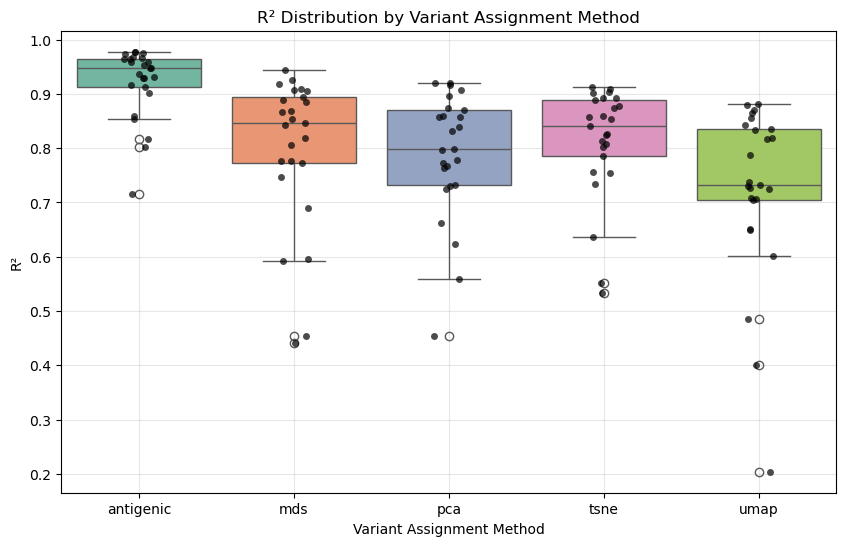

In [47]:
# Plot distribution of r2 for antigenic vs sequence clusters
plt.figure(figsize=(10, 6))
sns.boxplot(data=diagnostics_df, x='assignment_method', y='adj_r2', palette='Set2')
# Add individual points
sns.stripplot(data=diagnostics_df, x='assignment_method', y='adj_r2', color='black', alpha=0.7, jitter=True)
# Add labels and title
plt.title('R² Distribution by Variant Assignment Method')
plt.xlabel('Variant Assignment Method')
plt.ylabel('R²')
plt.grid(True, alpha=0.3)
plt.show()

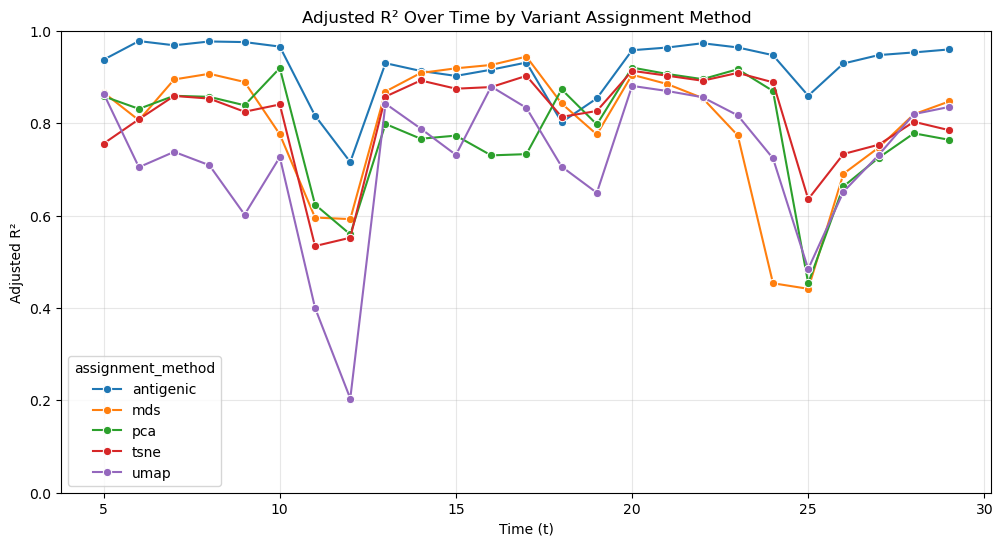

In [42]:
# Adjusted R² over time for both methods
plt.figure(figsize=(12, 6))
sns.lineplot(data=diagnostics_df, x='t', y='adj_r2', hue='assignment_method', marker='o')
# Add labels and title
plt.title('Adjusted R² Over Time by Variant Assignment Method')
plt.xlabel('Time (t)')
plt.ylabel('Adjusted R²')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

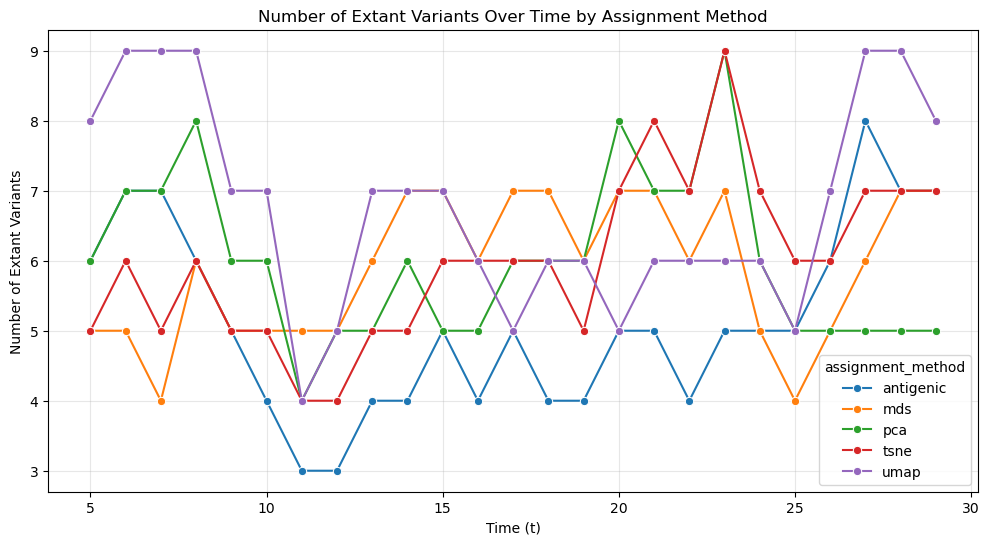

In [43]:
# Show number of clusters over time for both methods
plt.figure(figsize=(12, 6))
sns.lineplot(data=diagnostics_df, x='t', y='n_clusters', hue='assignment_method', marker='o')
# Add labels and title
plt.title('Number of Extant Variants Over Time by Assignment Method')
plt.xlabel('Time (t)')
plt.ylabel('Number of Extant Variants')
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
assignment_methods = ['variant_mds', 'variant_pca', 'variant_tsne', 'variant_umap']
external_metrics = {
    'assignment_method': [],
    'metric': [],
    'score': [],
}
for col in assignment_methods:
    nmi = normalized_mutual_info_score(merged_tips_df['variant'], merged_tips_df[col])
    ari = adjusted_rand_score(merged_tips_df['variant'], merged_tips_df[col])
    external_metrics['metric'].append('NMI')
    external_metrics['score'].append(nmi)
    external_metrics['assignment_method'].append(col)
    external_metrics['metric'].append('ARI')
    external_metrics['score'].append(ari)
    external_metrics['assignment_method'].append(col)

    print(f"{col} vs Ground truth antigenic clusters:")
    print(f"  NMI: {nmi:.4f}")
    print(f"  ARI: {ari:.4f}")

variant_mds vs Ground truth antigenic clusters:
  NMI: 0.8213
  ARI: 0.6469
variant_pca vs Ground truth antigenic clusters:
  NMI: 0.8350
  ARI: 0.6636
variant_tsne vs Ground truth antigenic clusters:
  NMI: 0.8276
  ARI: 0.6609
variant_umap vs Ground truth antigenic clusters:
  NMI: 0.7526
  ARI: 0.5558


In [45]:
external_metrics_df = pd.DataFrame(external_metrics)
external_metrics_df

,assignment_method,metric,score
0,variant_mds,NMI,0.821269
1,variant_mds,ARI,0.646862
2,variant_pca,NMI,0.835030
3,variant_pca,ARI,0.663645
4,variant_tsne,NMI,0.827556
5,variant_tsne,ARI,0.660885
6,variant_umap,NMI,0.752646
7,variant_umap,ARI,0.555821


In [46]:
external_metrics_df.to_csv(out_path + "variant_assignment_external_scores.tsv", sep="\t", index=False)